# Inverse-Cramer — is fading the loudest pundit an edge? 📺
### A viral 'just do the opposite of Jim Cramer' meme, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Selection_bias%3F: Not_supported](https://img.shields.io/badge/Selection_bias%3F-Not_supported-8b949e?style=flat-square)

One of the internet's favourite market jokes: CNBC's Jim Cramer is *so* often wrong that you should just **do the opposite of whatever he says**. The joke got real enough to spawn an actual ETF — **SJIM**, the *Inverse Cramer Tracker* — which launched in 2023 and quietly closed eleven months later. This notebook takes a curated table of his most famous calls, fades every one of them, and asks the only two questions that matter: *is fading him a real edge, or does the meme just remember his worst days?*

> 📓 **This is the plain-language layer.** Want the t-stats, the bootstrap and the selection-bias maths? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
# Point quantlab's parquet cache at THIS study's _cache so the real-tape cells hit the
# pinned tapes regardless of the working directory (and fall back to frozen numbers if absent).
os.environ.setdefault("OVERNIGHT_CACHE", os.path.abspath("../_cache"))
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from inverse_cramer import data, strategy as st

# Try the real tape (cache or network); fall back to the frozen numbers from results.md.
def _load_real():
    try:
        tapes = data.load_real(end="2026-06-20", fetch=False)
        led = st.build_real_ledger(data.calls_table(), tapes, fwd=21)
        if len(led) >= 5:
            return led, tapes, True
    except Exception as e:
        print("real tape unavailable, using frozen numbers:", type(e).__name__)
    return None, None, False

REAL_LEDGER, REAL_TAPES, HAVE_REAL = _load_real()
print("real curated tape present:", HAVE_REAL,
      f"(n={len(REAL_LEDGER) if HAVE_REAL else 'frozen'})")


real curated tape present: True (n=20)


## The answer first 🎯

| Question | Answer |
|---|---|
| Does fading his famous calls make money? | **On paper, a lot** — about **+420 bps per call**, winning **65%** of the time. |
| Is that statistically real? | **No — not at the one-month horizon.** The *t*-stat is only **+1.47** (you want ≥ 2), and the error bars on the average run from **-114 to +937 bps** — straight through zero. |
| Could you actually trade it? | **No.** The list of 'his worst calls' only exists *after* the calls went bad. You can't trade hindsight. |
| So why does the meme feel so true? | **Selection.** We show a pundit who is a pure **coin flip** still looks fade-able once you publish only his worst moments. |

> The Inverse-Cramer meme isn't a strategy — it's a highlight reel. A curated list of anyone's most memorable mistakes will look unbeatable, and that's exactly the trick.

## 1 · The claim

> *"Jim Cramer is the world's greatest contrarian indicator. Whatever he tells you to buy, sell — and whatever he tells you to sell, buy. The Inverse Cramer never loses."*

— finance Twitter, c. 2021–2023, and the (real, now-defunct) **SJIM** ETF prospectus in polite institutional language

The steelman: a famous TV personality makes high-conviction calls to a huge retail audience, often near tops (attention peaks when a stock is already euphoric). If his endorsements mark crowd-driven exhaustion, the move *after* the call should reverse — so fading him would pay. That's a real, testable mechanism, not just a joke.

## 2 · So what?

Two reasons this is worth a careful look. First, an *actual fund* was built on it and *closed* — so reality already voted, and we get to explain why the meme and the fund disagree. Second, the Inverse-Cramer is the purest possible specimen of a trap that shows up everywhere: a **curated highlight reel** that looks like evidence. Learn to see through it here and you'll spot it in every 'look how wrong the experts were' thread you ever read.

## 3 · How would we even know?

Three checks keep us honest:

1. **Fade the famous calls and measure.** Take a curated table of notable Cramer calls, trade the *opposite* of each (entered the day *after* he speaks — no peeking), hold a month, and look at the average **and** its error bars.
2. **Race it against a coin.** Trade a *random* direction on the same calls. If fading knows something, it beats the coin by more than noise.
3. **Build a coin-flip pundit on purpose.** Simulate a pundit who is *exactly* a coin, then publish only his worst calls — and see whether that alone fakes an 'edge'. Spoiler: it does.

Tape: real daily total-return prices for the call tickers, since 2007.

## 4 · The teardown — let's actually look

**First: how good does the fade look on the famous calls?**

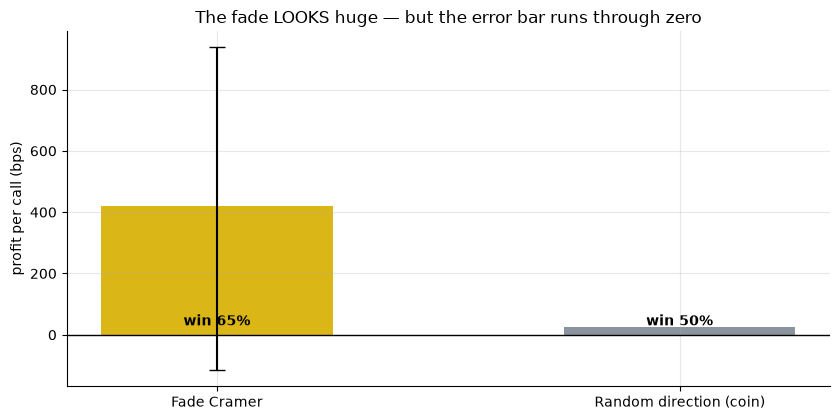

Fade: +420 bps  win 65%  HAC t=+1.47  95% CI [-114, +937]


In [2]:
if HAVE_REAL:
    res = st.excess_over_coin(REAL_LEDGER)
    f, c = res['fade'], res['coin']
    f_mean, f_win, f_t, lo, hi = f['mean_bps'], f['win_rate']*100, f['tstat'], f['ci_lo'], f['ci_hi']
    c_mean, c_win = c['mean_bps'], c['win_rate']*100
else:
    f_mean, f_win, f_t, lo, hi = 420.2, 65.0, 1.47, -114, 937
    c_mean, c_win = 24.8, 45.0
fig, ax = plt.subplots(figsize=(8.5, 4.3))
b = ax.bar(['Fade Cramer', 'Random direction (coin)'], [f_mean, c_mean],
           color=[AMBER, GREY], width=.5)
ax.errorbar(0, f_mean, yerr=[[f_mean-lo],[hi-f_mean]], fmt='none', ecolor='k', capsize=6, lw=1.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('profit per call (bps)')
ax.set_title('The fade LOOKS huge — but the error bar runs through zero')
for bar_, w in zip(b, [f_win, c_win]):
    ax.annotate(f'win {w:.0f}%', (bar_.get_x()+bar_.get_width()/2, 20),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Fade: {f_mean:+.0f} bps  win {f_win:.0f}%  HAC t={f_t:+.2f}  95% CI [{lo:+.0f}, {hi:+.0f}]')

There's the catch. The fade earns a fat **+420 bps/call** and wins **65%** of the time — but the *t*-stat is only **+1.47** (below the 2 you need), and the error bar on the average runs from **-114 to +937 bps** — straight through zero. Twenty hand-picked calls just isn't enough to tell a real edge from a lucky reel.

**Now the punchline. Let's build a pundit who is *literally a coin flip*** — zero skill, zero anti-skill — and then publish only his *worst* calls, the way a meme would. What 'edge' does fading a coin produce?

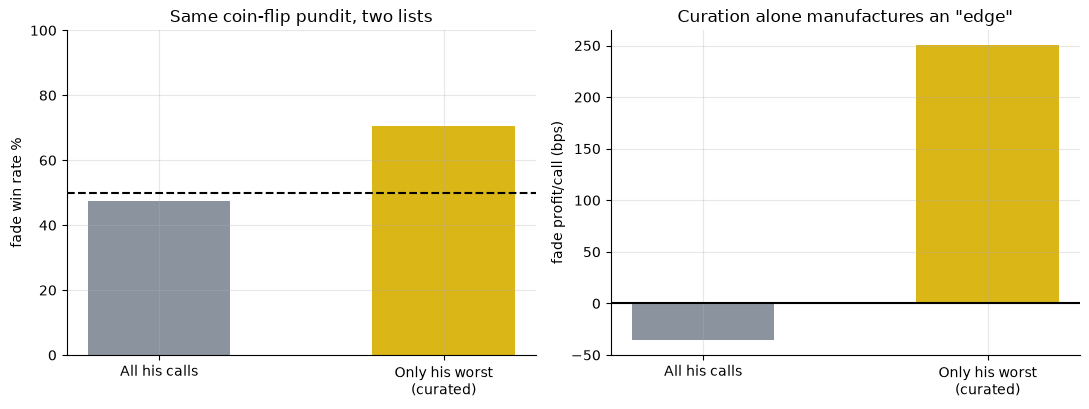

All calls : win 48%  mean -36 bps  t=-0.54
Curated   : win 70%  mean +250 bps  t=+4.14


In [3]:
# A coin-flip pundit, then curate the published list to his worst calls.
_, calls_null, _ = data.synthetic_calls(anti_alpha=0.0, selection_bias=0.0, seed=336)
_, calls_cur,  _ = data.synthetic_calls(anti_alpha=0.0, selection_bias=0.6, seed=336)
s_null = st.summarize(st.fade_returns(st.synthetic_ledger(calls_null)))
s_cur  = st.summarize(st.fade_returns(st.synthetic_ledger(calls_cur)))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.bar(['All his calls','Only his worst\n(curated)'], [s_null['win_rate']*100, s_cur['win_rate']*100],
       color=[GREY, AMBER], width=.5)
a1.axhline(50, ls='--', c='k'); a1.set_ylim(0,100); a1.set_ylabel('fade win rate %')
a1.set_title('Same coin-flip pundit, two lists')
a2.bar(['All his calls','Only his worst\n(curated)'], [s_null['mean_bps'], s_cur['mean_bps']],
       color=[GREY, AMBER], width=.5)
a2.axhline(0, c='k'); a2.set_ylabel('fade profit/call (bps)')
a2.set_title('Curation alone manufactures an "edge"')
plt.tight_layout(); plt.show()
print(f"All calls : win {s_null['win_rate']*100:.0f}%  mean {s_null['mean_bps']:+.0f} bps  t={s_null['tstat']:+.2f}")
print(f"Curated   : win {s_cur['win_rate']*100:.0f}%  mean {s_cur['mean_bps']:+.0f} bps  t={s_cur['tstat']:+.2f}")

There it is. The *same* coin-flip pundit, taken at face value, is a coin to fade (48% wins, a *losing* average). But publish only his worst calls and the fade suddenly wins **70%** at **+250 bps**, with a *t*-stat of **+4.14** — comfortably 'significant'. No skill was harmed in the making of this edge; it's **pure curation**. That's the whole Inverse-Cramer meme in one chart.

## 5 · The verdict

- **Signal — Weak.** The curated fade earns +420 bps/call but only *t* = +1.47 at one month, with a CI through zero. The meme (and the SJIM ETF) assert a real edge; this tape can't certify it.
- **Tradability — Mirage.** You can't trade a list that only exists in hindsight. A real 'fade everything he says' rule would take *hundreds* of calls a week, not the 20 a meme remembers.
- **Selection bias? — Not supported (as an edge).** A coin-flip pundit, curated, fakes a *t* = +4 fade. The famous edge is consistent with pure selection.

## 6 · Could you actually trade it?

Costs aren't the problem — the per-call moves are large, so even a generous round-trip fee barely dents them:

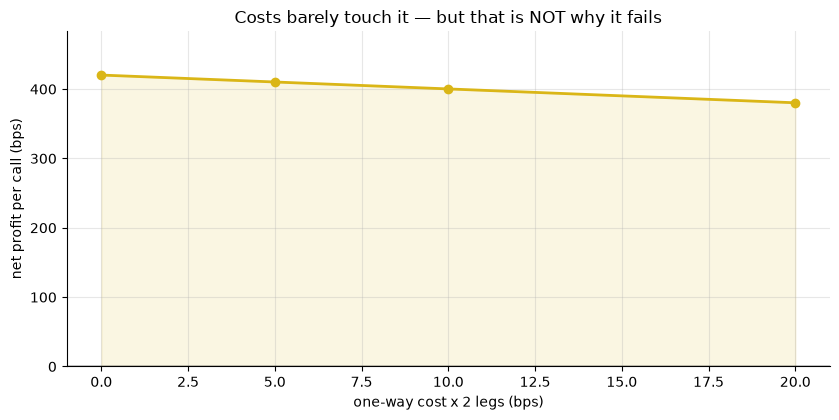

The edge dies on selection and sample size, not on costs.


In [4]:
costs = [0.0, 5.0, 10.0, 20.0]
if HAVE_REAL:
    net = [st.summarize(st.fade_returns(REAL_LEDGER, cost_bps=c))['mean_bps'] for c in costs]
else:
    net = [420.2, 410.2, 400.2, 380.2]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=AMBER, lw=2)
ax.fill_between(costs, net, 0, color=AMBER, alpha=.12); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('one-way cost x 2 legs (bps)'); ax.set_ylabel('net profit per call (bps)')
ax.set_ylim(0, max(net)*1.15)
ax.set_title('Costs barely touch it — but that is NOT why it fails')
plt.tight_layout(); plt.show()
print('The edge dies on selection and sample size, not on costs.')

Unlike the desk's cost-killed mirages, this one shrugs off fees. It fails for a deeper reason: **the strategy as stated isn't a strategy.** 'Fade his worst calls' is a description of the past. The honest version — fade *every* call he makes, live — is a completely different (and far less flattering) experiment, and it's the one SJIM actually ran. It closed.

## 7 · Going further 🚪

- **The real test is the live, all-calls fade.** Scrape *every* on-air recommendation (not the memorable ones) and fade them with no hindsight. That's the experiment SJIM ran — and the one a curated table can never stand in for.
- **Where the curation trap shows up elsewhere.** The desk's alt-data lot ([Study 252 — Google-Trends](../../252-google-trends/) onward) keeps finding the same thing: a crowd/attention signal that looks predictive until you account for how the sample was chosen.
- **The closest cousin.** [Study 291 — Doge-Tweets](../../291-doge-tweets/) — a single loud voice 'moving' the tape, with the same selection caveats.

*Think the fade is real? Fork this, swap in a complete, time-stamped call log (no cherry-picking), and show the t-stat surviving once the curation is gone.*